# 在 macOS 本地進行 YOLO 臉部情緒辨識

本專案說明如何在 MacBook Air M2（24GB RAM / 512GB SSD）上，使用 YOLOv8 完成臉部情緒辨識模型的訓練、評估與部署。

## Goals 專案目標
- 透過**單一 Jupyter Notebook**，在本地端完成完整流程
- 使用 **Kaggle 臉部情緒資料集**進行模型訓練
- 將情緒類別簡化為以下五種：
  - Angry  
  - Fear  
  - Happy  
  - Sad  
  - Surprise  

## Function 功能範圍
- 本地資料集處理與 YOLO 格式轉換
- YOLOv8 人臉偵測＋情緒分類訓練
- 模型評估（訓練指標與效能）
- 支援多種推論輸入：
  - Image
  - Video
  - Webcam（即時）

## Environment 執行環境
- 作業系統：macOS
- 裝置：MacBook Air M2
- 執行方式：單一 Jupyter Notebook（由上至下依序執行）

## 目錄 Table of Contents

1. [環境設定 Environment Setup](#1-environment-setup)  
2. [資料集準備與驗證 Dataset Preparation & Validation](#2-dataset-preparation--validation)  
3. [標註視覺化 Annotation Visualization](#3-annotation-visualization)  
4. [配置與設定 YOLO Configuration](#4-yolo-configuration)  
5. [訓練 Training](#5-training)  
6. [評估與訓練監控 Evaluation & Monitoring](#6-evaluation--monitoring)  
7. [推論流程 Inference Pipelines](#7-inference-pipelines)  
8. [效能與穩定性 Performance & Stability Controls](#8-performance--stability-controls)  
9. [模型管理 Model & Result Management（）](#9-model--result-management)  
10. [使用方式與疑難排解 Usage & Troubleshooting Notes](#10-usage--troubleshooting-notes)

### 目錄跟環境說明
- 建議使用 Python 3.12 或是以下版本。
- 所有的專案資源都在 `final/` 目錄之下，符合 YOLO 格式的資料集被指定在 `Data/processed` (包含train/val/test).
- 每個章節在執行程式碼前都會有 Markdown 說明，先說清楚需要的輸入與預期輸出。
- 若中途中斷再繼續，請先重新執行 **Setup** 與 **Configuration** 相關的 cell，以恢復執行環境與設定。

## 1. 環境設定 Environment Setup

### 安裝所需的 Python 依賴｜Install Python Dependencies
在新環境或依賴增加時運行一次，專案中使用的 Torch 支持 Apple Metal Performance Shaders（MPS）。

若升級後發生匯入失敗，請重新啟動 kernel。

Run once per environment (rerun if new packages are added). Torch wheels pulled here support Apple Metal Performance Shaders (MPS). Restart the kernel after upgrades if imports fail.


In [1]:

%%bash
python3 -m pip install --upgrade pip
python3 -m pip install     torch torchvision torchaudio     ultralytics opencv-python matplotlib numpy pandas seaborn     psutil pyyaml tqdm python-dotenv ipywidgets


  Using cached torch-2.9.1-cp312-none-macosx_11_0_arm64.whl.metadata (30 kB)
  Using cached torchvision-0.24.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.9 kB)
  Using cached ultralytics-8.3.240-py3-none-any.whl.metadata (37 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached numpy-2.4.0-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pandas-2.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached filelock-3.20.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptool

### 驗證環境與硬體狀態｜Verify Runtime & Hardware Status
透過這個段落可以確認 Python 與 Torch 版本, 以及當前裝置的 Apple MPS 是否可用。

運行段落後顯示的內容會重複在訓練過程中使用。

Checks Python version, Torch build, and whether Apple MPS is enabled. The device string printed here is reused across training/inference.


In [3]:

import platform
import psutil
import torch

python_version = platform.python_version()
torch_version = torch.__version__
is_mps = torch.backends.mps.is_available()
is_cuda = torch.cuda.is_available()
selected_device = "mps" if is_mps else ("cuda" if is_cuda else "cpu")
device = torch.device(selected_device)

print(f"Python version : {python_version}")
print(f"Torch version  : {torch_version}")
print(f"MPS available  : {is_mps}")
print(f"CUDA available : {is_cuda}")
print(f"Active device  : {device}")
print(f"Logical cores  : {psutil.cpu_count(logical=True)}")
print(f"Memory (GB)    : {psutil.virtual_memory().total / 1e9:.2f}")


Python version : 3.12.12
Torch version  : 2.9.1
MPS available  : True
CUDA available : False
Active device  : mps
Logical cores  : 8
Memory (GB)    : 25.77


## 2. 準備與驗證資料｜Dataset Preparation & Validation

符合 YOLO 格式的資料集位於 `Data/processed`，並採用標準的資料切分結構：

The YOLO-formatted dataset lives in `Data/processed` with the standard split layout:
```
Data/processed/
    images/{train,val,test}
    labels/{train,val,test}
```
本章節會設定共用的路徑、產生 `dataset.yaml`，並檢查影像與標註是否對齊，以及各類別的分布情況是否正確。

This section sets shared paths, writes a `dataset.yaml`, and validates image/label alignment plus class distributions.


In [4]:

from __future__ import annotations

import json
import math
import os
import random
import time
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from tqdm import tqdm

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "Data"
PROCESSED_ROOT = DATA_ROOT / "processed"
IMAGES_DIR = PROCESSED_ROOT / "images"
LABELS_DIR = PROCESSED_ROOT / "labels"
DATASET_YAML_PATH = DATA_ROOT / "dataset.yaml"
RUNS_DIR = PROJECT_ROOT / "runs"
MODEL_STORE = PROJECT_ROOT / "models"
INFERENCE_ROOT = RUNS_DIR / "inference"
INFERENCE_IMAGES_DIR = INFERENCE_ROOT / "images"
INFERENCE_VIDEOS_DIR = INFERENCE_ROOT / "videos"
DEFAULT_MODEL_SIZE = "n"  # n -> YOLOv8n, s -> YOLOv8s
CLASS_NAMES = ["Angry", "Fear", "Happy", "Sad", "Surprise"]
CLASS_ID_TO_NAME = {idx: name for idx, name in enumerate(CLASS_NAMES)}

for path in [RUNS_DIR, MODEL_STORE, INFERENCE_IMAGES_DIR, INFERENCE_VIDEOS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

@dataclass
class RuntimeControls:
    imgsz: int = 512
    batch: int = 16
    epochs: int = 8
    patience: int = 15
    learning_rate: float = 0.01
    weight_decay: float = 5e-4
    warmup_epochs: float = 3.0
    dropout: float = 0.0
    label_smoothing: float = 0.0
    frame_skip: int = 1
    resize_short_side: Optional[int] = 640
    max_webcam_fps: int = 30
    conf_threshold: float = 0.5

runtime_controls = RuntimeControls()
print(json.dumps({"project_root": str(PROJECT_ROOT), "dataset_root": str(PROCESSED_ROOT)}, indent=2))


{
  "project_root": "/Users/chsuiinx/Documents/chsuiinx.code/course.ML/final",
  "dataset_root": "/Users/chsuiinx/Documents/chsuiinx.code/course.ML/final/Data/processed"
}


In [5]:

dataset_config = {
    "path": str(PROCESSED_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": CLASS_NAMES,
}
with open(DATASET_YAML_PATH, "w", encoding="utf-8") as fh:
    yaml.safe_dump(dataset_config, fh, sort_keys=False)
print(f"dataset.yaml written to {DATASET_YAML_PATH}")
print(json.dumps(dataset_config, indent=2))


dataset.yaml written to /Users/chsuiinx/Documents/chsuiinx.code/course.ML/final/Data/dataset.yaml
{
  "path": "/Users/chsuiinx/Documents/chsuiinx.code/course.ML/final/Data/processed",
  "train": "images/train",
  "val": "images/val",
  "test": "images/test",
  "names": [
    "Angry",
    "Fear",
    "Happy",
    "Sad",
    "Surprise"
  ]
}


In [6]:

def _gather_split_stats(split: str) -> Dict[str, object]:
    image_dir = IMAGES_DIR / split
    label_dir = LABELS_DIR / split
    assert image_dir.exists(), f"Missing images directory: {image_dir}"
    assert label_dir.exists(), f"Missing labels directory: {label_dir}"

    image_files = {p.stem: p for p in image_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}}
    label_files = {p.stem: p for p in label_dir.glob("*.txt")}

    missing_labels = sorted(image_files.keys() - label_files.keys())
    missing_images = sorted(label_files.keys() - image_files.keys())

    class_counts = Counter()
    box_counts = 0
    for stem in sorted(image_files.keys() & label_files.keys()):
        for line in label_files[stem].read_text().strip().splitlines():
            if not line.strip():
                continue
            parts = line.split()
            cls_id = int(float(parts[0]))
            class_counts[cls_id] += 1
            box_counts += 1

    readable_counts = {CLASS_ID_TO_NAME.get(k, f"class_{k}"): v for k, v in class_counts.items()}
    return {
        "split": split,
        "images": len(image_files),
        "labels": len(label_files),
        "boxes": box_counts,
        "missing_labels": len(missing_labels),
        "missing_images": len(missing_images),
        "class_distribution": readable_counts,
    }

split_stats = [_gather_split_stats(split) for split in ("train", "val", "test")]

df = pd.DataFrame([{k: v for k, v in stat.items() if k != "class_distribution"} for stat in split_stats])
display(df)

for stat in split_stats:
    print(f"Split: {stat['split']}")
    print(json.dumps(stat["class_distribution"], indent=2))
    if stat["missing_labels"] or stat["missing_images"]:
        print(f"⚠️ Missing labels: {stat['missing_labels']} | Missing images: {stat['missing_images']}")
    else:
        print("✅ Images and labels are aligned.")


,split,images,labels,boxes,missing_labels,missing_images
0,train,41413,41413,42209,0,0
1,val,11832,11832,12069,0,0
2,test,5917,5917,6029,0,0


Split: train
{
  "Angry": 7146,
  "Fear": 6874,
  "Happy": 13169,
  "Sad": 9189,
  "Surprise": 5831
}
✅ Images and labels are aligned.
Split: val
{
  "Angry": 2053,
  "Fear": 1966,
  "Happy": 3765,
  "Sad": 2632,
  "Surprise": 1653
}
✅ Images and labels are aligned.
Split: test
{
  "Angry": 1022,
  "Fear": 991,
  "Happy": 1882,
  "Sad": 1305,
  "Surprise": 829
}
✅ Images and labels are aligned.


## 3. 標註視覺化｜Annotation Visualization

隨機在資料集中抽取資料，以確認 bounding box 與情緒標籤是否正確。

透過修改 `split` 參數（`train` / `val` / `test`），或指定特定檔案的檔名主體（不含副檔名，`stem`），來檢視指定的影像與標註內容。

Visualize random or user-selected samples to confirm bounding boxes and emotion labels. Edit the `split` argument (`train`/`val`/`test`) or provide an explicit `stem` filename (without extension) to inspect specific assets.


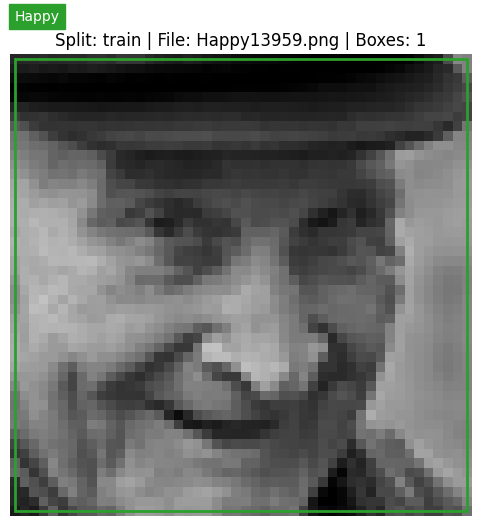

In [27]:

COLORS = plt.get_cmap("tab10")


def _yolo_to_xyxy(box: Iterable[float], width: int, height: int) -> Tuple[int, int, int, int]:
    _, x_c, y_c, bw, bh = box
    x_c *= width
    y_c *= height
    bw *= width
    bh *= height
    x1 = int(max(0, x_c - bw / 2))
    y1 = int(max(0, y_c - bh / 2))
    x2 = int(min(width - 1, x_c + bw / 2))
    y2 = int(min(height - 1, y_c + bh / 2))
    return x1, y1, x2, y2


def visualize_sample(split: str = "train", stem: Optional[str] = None, seed: Optional[int] = None) -> None:
    rng = random.Random(seed)
    label_dir = LABELS_DIR / split
    image_dir = IMAGES_DIR / split
    label_paths = sorted(label_dir.glob("*.txt"))
    if not label_paths:
        raise FileNotFoundError(f"No labels found under {label_dir}")
    if stem is None:
        label_path = rng.choice(label_paths)
    else:
        matches = [p for p in label_paths if p.stem == stem]
        if not matches:
            raise FileNotFoundError(f"Could not find label file for stem '{stem}' in {label_dir}")
        label_path = matches[0]
    image_candidates = [image_dir / f"{label_path.stem}{ext}" for ext in (".jpg", ".jpeg", ".png", ".bmp")]
    image_path = next((p for p in image_candidates if p.exists()), None)
    if image_path is None:
        raise FileNotFoundError(f"No image found for {label_path.stem} in {image_dir}")

    image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape
    annotations = []
    for line in label_path.read_text().strip().splitlines():
        if not line.strip():
            continue
        parts = [float(x) for x in line.split()]
        cls_id = int(parts[0])
        label = CLASS_ID_TO_NAME.get(cls_id, f"class_{cls_id}")
        annotations.append((cls_id, label, _yolo_to_xyxy(parts, w, h)))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image)
    for cls_id, label, (x1, y1, x2, y2) in annotations:
        color = COLORS(cls_id % 10)
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2))
        ax.text(x1, y1 - 4, label, color="white", backgroundcolor=color, fontsize=10)
    ax.set_title(f"Split: {split} | File: {image_path.name} | Boxes: {len(annotations)}")
    ax.axis("off")
    plt.show()


visualize_sample(split="train", seed=13)


## 4. 配置與設定｜YOLO Configuration

本章節會設定適合在 MacBook Air M2 上執行的輕量化 YOLOv8 模型版本。  
可透過調整 `TRAINING_CONFIG` 這個設定字典，來修改訓練輪數（epochs）、輸入影像大小（image size）或其他超參數。

情緒類別數量會自動從 `CLASS_NAMES` 取得，因此只要更新這個清單，即可新增或移除情緒類別，無需額外修改其他設定。

Configure lightweight YOLOv8 variants suitable for the MacBook Air M2. Adjust the `TRAINING_CONFIG` dict to tune epochs, image size, or hyperparameters. Class count is inferred from `CLASS_NAMES`, so updating that list is enough to add/remove emotions.


In [7]:

from ultralytics import YOLO

MODEL_VARIANTS = {
    "n": "yolov8n.pt",
    "s": "yolov8s.pt",
}
MODEL_SIZE = DEFAULT_MODEL_SIZE  # switch to "s" for YOLOv8s
TRAINING_RUN_NAME = f"emotion_yolov8{MODEL_SIZE}"
TRAINING_OUTPUT = RUNS_DIR / "detect" / TRAINING_RUN_NAME

TRAINING_CONFIG = {
    "data": str(DATASET_YAML_PATH),
    "epochs": runtime_controls.epochs,
    "imgsz": runtime_controls.imgsz,
    "batch": runtime_controls.batch,
    "patience": runtime_controls.patience,
    "device": str(device),
    "project": str(RUNS_DIR / "detect"),
    "name": TRAINING_RUN_NAME,
    "exist_ok": True,
    "optimizer": "SGD",
    "lr0": runtime_controls.learning_rate,
    "lrf": 0.01,
    "momentum": 0.937,
    "weight_decay": runtime_controls.weight_decay,
    "warmup_epochs": runtime_controls.warmup_epochs,
    "dropout": runtime_controls.dropout,
    "label_smoothing": runtime_controls.label_smoothing,
    "seed": 42,
}

print(json.dumps(TRAINING_CONFIG, indent=2))


{
  "data": "/Users/chsuiinx/Documents/chsuiinx.code/course.ML/final/Data/dataset.yaml",
  "epochs": 8,
  "imgsz": 512,
  "batch": 16,
  "patience": 15,
  "device": "mps",
  "project": "/Users/chsuiinx/Documents/chsuiinx.code/course.ML/final/runs/detect",
  "name": "emotion_yolov8n",
  "exist_ok": true,
  "optimizer": "SGD",
  "lr0": 0.01,
  "lrf": 0.01,
  "momentum": 0.937,
  "weight_decay": 0.0005,
  "warmup_epochs": 3.0,
  "dropout": 0.0,
  "label_smoothing": 0.0,
  "seed": 42
}


### 初始化 Initialize YOLO Model
此段程式碼會載入指定的 YOLO 模型權重（checkpoint）。  

如果你已經訓練過自訂模型，可以將 `CUSTOM_WEIGHTS` 指向對應的 `.pt` 權重檔，即可繼續微調（fine-tuning），或直接用於推論。

The following cell loads the requested YOLO checkpoint. If you already trained a custom model, set `CUSTOM_WEIGHTS` to its `.pt` file to resume fine-tuning or run inference directly.


In [16]:

CUSTOM_WEIGHTS = Path("runs/detect/emotion_yolov8n_ft_full/weights/best.pt")
model_source = CUSTOM_WEIGHTS if CUSTOM_WEIGHTS else MODEL_VARIANTS[MODEL_SIZE]
print(f"Loading YOLO model from: {model_source}")
model = YOLO(model_source)


Loading YOLO model from: runs/detect/emotion_yolov8n_ft_full/weights/best.pt


## 5. 訓練｜Training

使用先前配置的設定進行訓練。

Start training with the configuration defined above. 

Losses（損失）應隨著時間逐步下降，

Training losses should trend downward, 

Ultralytics 會自動儲存包括`last.pt` 與表現最佳 `best.pt`的模型權重檔於：

and Ultralytics will automatically save checkpoints (last/best) in 
`runs/detect/{TRAINING_RUN_NAME}/weights/`.


In [21]:

# Uncomment to kick off training. Expect the run directory printed below.
train_results = model.train(**TRAINING_CONFIG)
train_results


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.1 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/chsuiinx/Documents/chsuiinx.code/course.ML/final/Data/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=8, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=emotion_yolov8n, nbs=64, nms=False, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x13e3e5670>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

## 5.1 微調｜Fine-tuning

使用上一輪訓練的權重（`last.pt` 或 `best.pt`）做為初始化，
啟動一個新的訓練 run 進行全網路微調。

Use the previous run's weights as initialization and start a new run (no resume) for full-network fine-tuning.


In [ ]:
# Fine-tuning: start a new run from the previous weights (no resume)
finetune_weights = TRAINING_OUTPUT / "weights" / "last.pt"
if not finetune_weights.exists():
    raise FileNotFoundError(f"Weights not found at {finetune_weights}. Train first or point to best.pt.")

finetune_config = {k: v for k, v in TRAINING_CONFIG.items() if k != "epochs"}
finetune_config.update({
    "epochs": 16,
    "lr0": 1e-3,
    "name": f"{TRAINING_RUN_NAME}_ft_full",
})

finetune_results = YOLO(str(finetune_weights)).train(**finetune_config)
finetune_results


## 6. 評估與訓練過程｜Evaluation & Monitoring

使用下方提供的輔助函式，可在驗證集（validation）或測試集（test）上進行模型評估，並輸出各項指標，包括 mAP、precision、recall、混淆矩陣（confusion matrix）以及訓練損失曲線（loss curves）。

Use the helper below to evaluate on validation or test splits and to surface metrics such as mAP, precision, recall, confusion matrix, and loss curves.


In [17]:

def evaluate_model(weights_path: Optional[Path] = None, split: str = "val", conf: float = 0.25):
    weights = weights_path or (TRAINING_OUTPUT / "weights" / "best.pt")
    if not Path(weights).exists():
        raise FileNotFoundError(f"Weights not found at {weights}")
    eval_model = YOLO(str(weights))
    results = eval_model.val(split=split, conf=conf, device=str(device), imgsz=runtime_controls.imgsz, verbose=True)
    metrics = results.results_dict
    display(pd.DataFrame([metrics], index=[split]))

    try:
        matrix = results.confusion_matrix.matrix
        labels = results.confusion_matrix.names
        plt.figure(figsize=(6, 5))
        sns.heatmap(matrix, annot=True, fmt=".2f", xticklabels=labels, yticklabels=labels, cmap="mako")
        plt.title(f"Confusion Matrix ({split})")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()
    except Exception as exc:
        print(f"Confusion matrix unavailable: {exc}")

    return results


# Example (run after training):
val_results = evaluate_model(split="val")
test_results = evaluate_model(split="test")


Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.1 MPS (Apple M2)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 27.2±5.1 MB/s, size: 5.0 KB)
val: Scanning /Users/chsuiinx/Documents/chsuiinx.code/course.ML/final/Data/processed/labels/val.cache... 11832 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11832/11832 32.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 740/740 3.5it/s 3:32<0.4s
                   all      11832      12069      0.599      0.771      0.685       0.63
                 Angry       2029       2053       0.53      0.726      0.653      0.585
                  Fear       1947       1966      0.423      0.531      0.416      0.382
                 Happy       3688       3765      0.847      0.917      0.925      0.843
                   Sad       2523       2632      0.532      0.813      0.612      0.582
        

,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
val,0.598966,0.770806,0.685383,0.630496,0.630496


<Figure size 600x500 with 2 Axes>

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.1 MPS (Apple M2)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 20.9±8.6 MB/s, size: 5.1 KB)
val: Scanning /Users/chsuiinx/Documents/chsuiinx.code/course.ML/final/Data/processed/labels/test.cache... 5917 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5917/5917 17.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 370/370 3.4it/s 1:47<0.3ss
                   all       5917       6029      0.622      0.745       0.69      0.636
                 Angry       1015       1022      0.564      0.701      0.629      0.561
                  Fear        973        991      0.444      0.443      0.429      0.397
                 Happy       1844       1882       0.85       0.92      0.933      0.862
                   Sad       1262       1305      0.552      0.803      0.634      0.605
         

,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
test,0.621967,0.744678,0.689671,0.636013,0.636013


<Figure size 600x500 with 2 Axes>

In [ ]:

def plot_training_curves(run_dir: Optional[Path] = None):
    run_dir = run_dir or TRAINING_OUTPUT
    results_csv = Path(run_dir) / "results.csv"
    if not results_csv.exists():
        raise FileNotFoundError(f"results.csv not found at {results_csv}")
    df = pd.read_csv(results_csv)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df.index + 1, df["train/box_loss"], label="Box Loss")
    axes[0].plot(df.index + 1, df["train/cls_loss"], label="Cls Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].set_title("Training Losses")

    axes[1].plot(df.index + 1, df["metrics/mAP50(B)"] * 100, label="mAP50")
    axes[1].plot(df.index + 1, df["metrics/precision(B)"] * 100, label="Precision")
    axes[1].plot(df.index + 1, df["metrics/recall(B)"] * 100, label="Recall")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("%")
    axes[1].legend()
    axes[1].set_title("Validation Metrics")
    plt.suptitle("Training Monitoring")
    plt.show()

plot_training_curves()


## 7. Inference Pipelines 推論流程

載入已訓練完成的模型權重（或選擇指定的 checkpoint），以進行後續的推論。

下方提供的輔助函式涵蓋單張圖片、影片檔案與即時 webcam 串流等使用情境，並會在輸出結果中自動加上時間戳，方便整理與管理產出檔案。

Load trained weights (or pick a checkpoint) for downstream inference. The helpers below cover single-image, video file, and webcam streaming scenarios. Each helper stamps outputs with timestamps to keep artifacts organized.

In [9]:

def get_inference_weights() -> Path:
    candidate = TRAINING_OUTPUT / "weights" / "best.pt"
    if candidate.exists():
        return candidate
    raise FileNotFoundError("No trained weights found. Train the model or set CUSTOM_WEIGHTS.")


def load_inference_model(weights_path: Optional[Path] = None) -> YOLO:
    weights = weights_path or get_inference_weights()
    print(f"Using inference weights: {weights}")
    return YOLO(str(weights))


inference_model = None  # will be instantiated right before inference


### 7.1 使用靜態影像推論 Image Inference

推論指定本地資料夾中的靜態影像。
此輔助工具會回報推論延遲時間（毫秒），並可選擇將已加上標註的影像畫面儲存至 `runs/inference/images` 目錄下。

Provide a local image path to visualize detections inline. The helper reports latency (ms) and optionally saves annotated frames under `runs/inference/images`.


In [ ]:

def run_image_inference(image_path: Path, conf: float = 0.5, save: bool = True, show: bool = True,
                        weights_path: Optional[Path] = None) -> Dict[str, object]:
    global inference_model
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(image_path)
    if inference_model is None or weights_path is not None:
        inference_model = load_inference_model(weights_path)

    start = time.perf_counter()
    results = inference_model.predict(source=str(image_path), conf=conf, device=str(device), verbose=False)
    elapsed_ms = (time.perf_counter() - start) * 1000
    annotated = results[0].plot(line_width=2)

    output_path = None
    if save:
        timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
        output_path = INFERENCE_IMAGES_DIR / f"{image_path.stem}_{timestamp}.png"
        cv2.imwrite(str(output_path), annotated)

    if show:
        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title(f"Latency: {elapsed_ms:.1f} ms | conf>={conf}")
        plt.axis("off")
        plt.show()

    return {"image": str(image_path), "output": str(output_path) if output_path else None, "latency_ms": elapsed_ms}


# Example:
run_image_inference(Path("/Users/chsuiinx/Documents/chsuiinx.code/course.ML/final/images.jpeg"))


### 7.2 Video File Inference

Processes `.mp4`/`.mov` videos frame-by-frame with optional frame skipping and resizing to keep FPS ≥10. Set `save=True` to write an annotated video. When `display=True`, frames are shown inline (slower; best for short clips).


In [12]:
def run_video_inference(video_path: Path, conf: float = 0.5, save: bool = True, display: bool = False,
                        frame_skip: Optional[int] = None, resize_short_side: Optional[int] = None,
                        weights_path: Optional[Path] = None) -> Dict[str, object]:
    global inference_model
    video_path = Path(video_path)
    if not video_path.exists():
        raise FileNotFoundError(video_path)
    if inference_model is None or weights_path is not None:
        inference_model = load_inference_model(weights_path)

    frame_skip = frame_skip or runtime_controls.frame_skip
    resize_short_side = resize_short_side or runtime_controls.resize_short_side

    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
    fps = cap.get(cv2.CAP_PROP_FPS) or 30

    output_path = None
    writer = None

    processed = 0
    latencies = []
    display_frames = []

    with tqdm(total=total_frames, desc="Video inference", unit="frame") as pbar:
        idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_skip > 1 and idx % frame_skip != 0:
                idx += 1
                pbar.update(1)
                continue
            idx += 1
            if resize_short_side and min(frame.shape[:2]) != resize_short_side:
                scale = resize_short_side / min(frame.shape[:2])
                frame = cv2.resize(frame, (int(frame.shape[1] * scale), int(frame.shape[0] * scale)))
            start = time.perf_counter()
            results = inference_model.predict(frame, conf=conf, device=str(device), verbose=False)
            elapsed_ms = (time.perf_counter() - start) * 1000
            latencies.append(elapsed_ms)
            annotated = results[0].plot(line_width=2)
            if save and writer is None:
                timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
                output_path = INFERENCE_VIDEOS_DIR / f"{video_path.stem}_{timestamp}.mp4"
                fourcc = cv2.VideoWriter_fourcc(*"mp4v")
                height, width = annotated.shape[:2]
                writer = cv2.VideoWriter(
                    str(output_path),
                    fourcc,
                    max(10, fps / max(1, frame_skip)),
                    (width, height),
                )
                if not writer.isOpened():
                    raise RuntimeError(f"Failed to open VideoWriter: {output_path}")
            if writer is not None:
                writer.write(annotated)
            if display:
                display_frames.append(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
            processed += 1
            pbar.update(1)

    cap.release()
    if writer is not None:
        writer.release()

    if display and display_frames:
        plt.figure(figsize=(8, 8))
        plt.imshow(display_frames[-1])
        plt.axis("off")
        plt.title("Last processed frame")
        plt.show()

    avg_latency = float(np.mean(latencies)) if latencies else None
    achieved_fps = 1000.0 / avg_latency if avg_latency else None
    return {
        "video": str(video_path),
        "frames_processed": processed,
        "average_latency_ms": avg_latency,
        "approx_fps": achieved_fps,
        "output": str(output_path) if output_path else None,
    }


# Example:
run_video_inference(Path("【統神拳上精華】這是一個不公平的比賽阿 欸笑死人欸.mp4"), frame_skip=0)


Video inference: 100%|██████████| 1653/1653 [00:35<00:00, 46.29frame/s]


{'video': '【統神拳上精華】這是一個不公平的比賽阿 欸笑死人欸.mp4',
 'frames_processed': 1653,
 'average_latency_ms': 12.389735485772453,
 'approx_fps': 80.71197332245981,
 'output': '/Users/chsuiinx/Documents/chsuiinx.code/course.ML/final/runs/inference/videos/【統神拳上精華】這是一個不公平的比賽阿 欸笑死人欸_20251223-154000.mp4'}

### 7.3 Webcam Inference

Streams from the default webcam (index `0`) using OpenCV. Press **q** to stop. Frame skipping and resizing keep FPS stable on the M2.


In [ ]:
try:
    inference_model
except NameError:
    inference_model = None

if 'load_inference_model' not in globals():
    def get_inference_weights() -> Path:
        candidate = TRAINING_OUTPUT / 'weights' / 'best.pt'
        if candidate.exists():
            return candidate
        raise FileNotFoundError('No trained weights found. Train the model or set CUSTOM_WEIGHTS.')

    def load_inference_model(weights_path: Optional[Path] = None) -> YOLO:
        weights = weights_path or get_inference_weights()
        print(f'Using inference weights: {weights}')
        return YOLO(str(weights))


def run_webcam_inference(camera_index: int = 0, conf: float = 0.5, frame_skip: Optional[int] = None,
                          resize_short_side: Optional[int] = None, weights_path: Optional[Path] = None) -> None:
    global inference_model
    if inference_model is None or weights_path is not None:
        inference_model = load_inference_model(weights_path)

    frame_skip = frame_skip or runtime_controls.frame_skip
    resize_short_side = resize_short_side or runtime_controls.resize_short_side

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        raise RuntimeError("Unable to access webcam")

    print("Press 'q' to exit the webcam loop.")
    frame_idx = 0
    last_tick = time.time()
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_skip > 1 and frame_idx % frame_skip != 0:
            frame_idx += 1
            continue
        frame_idx += 1
        if resize_short_side:
            scale = resize_short_side / min(frame.shape[:2])
            frame = cv2.resize(frame, (int(frame.shape[1] * scale), int(frame.shape[0] * scale)))
        results = inference_model.predict(frame, conf=conf, device=str(device), verbose=False)
        annotated = results[0].plot(line_width=2)
        now = time.time()
        fps = 1.0 / (now - last_tick)
        last_tick = now
        cv2.putText(annotated, f"FPS: {fps:.1f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.imshow("Emotion Detection", annotated)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()


run_webcam_inference()


In [1]:
# Use a specific fine-tuned checkpoint for webcam inference
from pathlib import Path

run_webcam_inference(
    weights_path=Path("runs/detect/emotion_yolov8n_ft_full/weights/best.pt"),
    conf=0.5,
)

NameError: name 'run_webcam_inference' is not defined

## 8. Performance & Stability Controls

Centralized utility to tweak frame skipping, resize resolution, or other runtime controls without editing helper functions. Call `runtime_controls = runtime_controls.__class__(...)` to update multiple parameters at once.


In [ ]:

def update_runtime_controls(**kwargs) -> RuntimeControls:
    global runtime_controls
    data = asdict(runtime_controls)
    data.update(kwargs)
    runtime_controls = RuntimeControls(**data)
    print("Updated runtime controls:")
    print(json.dumps(asdict(runtime_controls), indent=2))
    return runtime_controls


# Example: limit webcam resolution + skip frames for stability
# update_runtime_controls(resize_short_side=480, frame_skip=2)


## 9. Model & Result Management

Keep artifacts organized for handoff: copy best weights to `models/`, capture metadata, and enumerate saved inference outputs. Use timestamps in filenames to avoid accidental overwrites.


In [ ]:

def export_best_weights(target_dir: Optional[Path] = None, tag: str = "best") -> Path:
    target_dir = target_dir or MODEL_STORE
    target_dir.mkdir(parents=True, exist_ok=True)
    source = TRAINING_OUTPUT / "weights" / f"{tag}.pt"
    if not source.exists():
        raise FileNotFoundError(f"No weights at {source}")
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    destination = target_dir / f"emotion_{TRAINING_RUN_NAME}_{tag}_{timestamp}.pt"
    import shutil
    shutil.copy2(source, destination)
    print(f"Weights exported to {destination}")
    return destination


def list_inference_results() -> pd.DataFrame:
    records = []
    for path in sorted(INFERENCE_IMAGES_DIR.glob("*")):
        records.append({"type": "image", "path": str(path), "created": datetime.fromtimestamp(path.stat().st_mtime)})
    for path in sorted(INFERENCE_VIDEOS_DIR.glob("*")):
        records.append({"type": "video", "path": str(path), "created": datetime.fromtimestamp(path.stat().st_mtime)})
    if not records:
        print("No inference artifacts saved yet.")
        return pd.DataFrame()
    df = pd.DataFrame(records)
    display(df)
    return df


# export_best_weights()
# list_inference_results()


## 10. Usage & Troubleshooting Notes

- **Running from scratch**
  1. Execute the dependency cell.
  2. Run hardware check + configuration to set paths.
  3. Validate the dataset and visualize a few samples.
  4. Train (`model.train`) with desired epochs/batch size.
  5. Evaluate using `evaluate_model` on val/test splits and inspect plots via `plot_training_curves`.
  6. Export weights and run inference helpers for images/videos/webcam.
- **Inference quick tips**
  - Keep `conf` around `0.4-0.6` for balanced precision/recall.
  - For real-time webcam use, drop resolution to 480 and `frame_skip=2` if FPS dips below 10.
  - Annotated artifacts live under `runs/inference/` with timestamps.
- **Common issues**
  - *Torch reports no MPS backend*: Ensure you installed torch>=2.1 on macOS 13+ and restart the kernel.
  - *Dataset mismatch errors*: Re-run the validation cell to identify missing labels/images and fix the offending files.
  - *Video writer produces empty file*: Confirm the source FPS is non-zero or override it when initializing `VideoWriter`.
- **Extending the workflow**
  - Update `CLASS_NAMES` + label files to add/remove emotions.
  - Tune `RuntimeControls` and `TRAINING_CONFIG` for hyperparameter sweeps.
  - Integrate experiment tracking (e.g., MLflow) by wrapping the training cell if needed.
